# Consumer Complaint Classification

This notebook builds a text classification pipeline that predicts a complaint category from a customer's written complaint narrative. Four models are trained and compared: SimpleRNN, LSTM, and GRU built from scratch, and a fine tuned DistilBERT transformer from HuggingFace. The best performing model is deployed through a Gradio interface.

Every expensive step (text preprocessing, tokenization, and each model's training) checkpoints to Google Drive and skips itself automatically once finished, so the notebook can be safely restarted from the top at any point without repeating completed work.

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

SAVE_DIR = "/content/drive/MyDrive/complaint_classification_project"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving everything to:", SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving everything to: /content/drive/MyDrive/complaint_classification_project


In [ ]:
import re
import json
import string
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, SpatialDropout1D, Bidirectional,
    SimpleRNN, LSTM, GRU, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")

print("Path to dataset files:", path)

100%|██████████| 19.8M/19.8M [00:00<00:00, 132MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1


In [ ]:
csv_path = os.path.join(path, "complaints_processed.csv")

df = pd.read_csv(csv_path)
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (162421, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(f"Rows after dropping missing values and duplicates: {len(df):,}")
print(f"Classes: {sorted(df['product'].unique())}")

Rows after dropping missing values and duplicates: 124,676
Classes: ['credit_card', 'credit_reporting', 'debt_collection', 'mortgages_and_loans', 'retail_banking']


## Exploratory data analysis

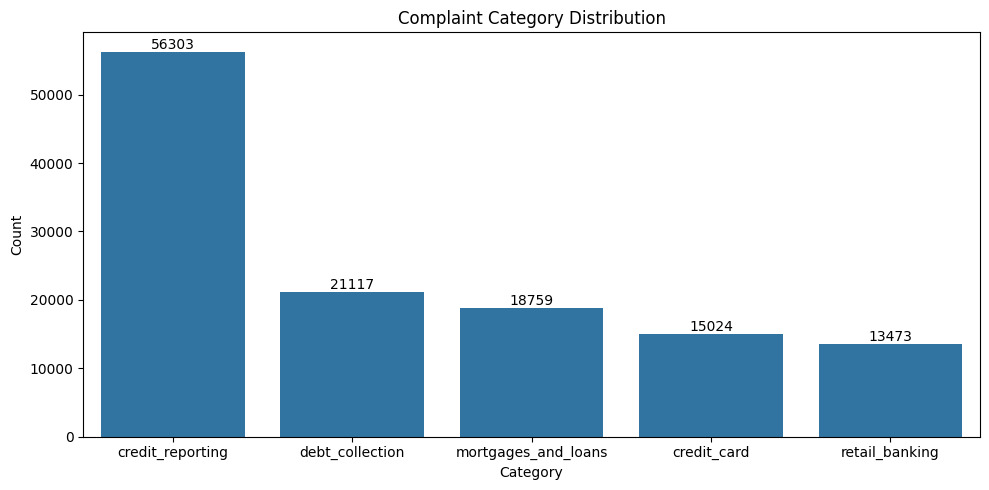

,proportion
product,
credit_reporting,45.16
debt_collection,16.94
mortgages_and_loans,15.05
credit_card,12.05
retail_banking,10.81


In [ ]:
plt.figure(figsize=(10, 5))
order = df["product"].value_counts().index
ax = sns.countplot(data=df, x="product", order=order)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Complaint Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

df["product"].value_counts(normalize=True).mul(100).round(2)

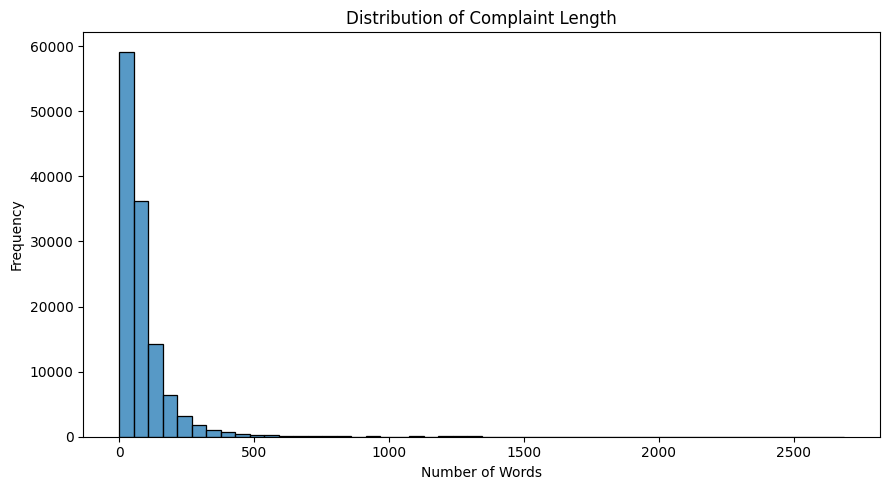

,word_count
count,124676.000000
mean,87.117055
std,110.875369
min,1.000000
25%,30.000000
50%,58.000000
75%,104.000000
max,2685.000000


In [ ]:
df["word_count"] = df["narrative"].apply(lambda text: len(str(text).split()))

plt.figure(figsize=(9, 5))
sns.histplot(df["word_count"], bins=50)
plt.title("Distribution of Complaint Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

df["word_count"].describe()

In [ ]:
df.drop(columns=["word_count"], inplace=True)

## Text preprocessing

The dataset already comes with the narratives reasonably clean, but a full preprocessing pass is applied anyway so the pipeline does not depend on the source formatting: lowercasing, URL removal, punctuation and digit removal, stopword removal, and lemmatization. Since lemmatizing roughly 120,000 rows takes a few minutes, the cleaned dataframe is cached to Drive so this step only ever runs once.

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

In [ ]:
CLEAN_CSV = f"{SAVE_DIR}/complaints_clean.csv"

if os.path.exists(CLEAN_CSV):
    print("Found cleaned dataset in Drive, loading it instead of reprocessing...")
    df = pd.read_csv(CLEAN_CSV)
else:
    print("Cleaning text, this only needs to run once...")
    df["clean_text"] = df["narrative"].apply(preprocess_text)
    df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
    df.to_csv(CLEAN_CSV, index=False)
    print("Saved cleaned dataset to Drive:", CLEAN_CSV)

print(f"Rows after cleaning: {len(df):,}")
df[["narrative", "clean_text"]].head(3)

Cleaning text, this only needs to run once...
Saved cleaned dataset to Drive: /content/drive/MyDrive/complaint_classification_project/complaints_clean.csv
Rows after cleaning: 124,676


,narrative,clean_text
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...


## Train, validation, test split

In [ ]:
X = df["clean_text"]
y = df["product"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train : {len(X_train):,}")
print(f"Valid : {len(X_valid):,}")
print(f"Test  : {len(X_test):,}")

Train : 87,273
Valid : 18,701
Test  : 18,702


In [ ]:
LABEL_ENCODER_PATH = f"{SAVE_DIR}/label_encoder.pkl"

if os.path.exists(LABEL_ENCODER_PATH):
    with open(LABEL_ENCODER_PATH, "rb") as f:
        label_encoder = pickle.load(f)
else:
    label_encoder = LabelEncoder()
    label_encoder.fit(y_train)
    with open(LABEL_ENCODER_PATH, "wb") as f:
        pickle.dump(label_encoder, f)

y_train_enc = label_encoder.transform(y_train)
y_valid_enc = label_encoder.transform(y_valid)
y_test_enc = label_encoder.transform(y_test)

NUM_CLASSES = len(label_encoder.classes_)
CLASS_NAMES = list(label_encoder.classes_)
print("Classes:", CLASS_NAMES)

Classes: ['credit_card', 'credit_reporting', 'debt_collection', 'mortgages_and_loans', 'retail_banking']


In [ ]:
class_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_enc), y=y_train_enc
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
class_weight_dict

{0: np.float64(1.6596557953789104),
 1: np.float64(0.4428752664163199),
 2: np.float64(1.1808009741577594),
 3: np.float64(1.3292666209732693),
 4: np.float64(1.8507687413847949)}

## Tokenization and padding

In [ ]:
TOKENIZER_PATH = f"{SAVE_DIR}/tokenizer.pkl"

if os.path.exists(TOKENIZER_PATH):
    with open(TOKENIZER_PATH, "rb") as f:
        tokenizer = pickle.load(f)
else:
    tokenizer = Tokenizer(oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train)
    with open(TOKENIZER_PATH, "wb") as f:
        pickle.dump(tokenizer, f)

VOCAB_SIZE = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {VOCAB_SIZE:,}")

Vocabulary size: 39,035


In [ ]:
train_sequences = tokenizer.texts_to_sequences(X_train)
sequence_lengths = [len(seq) for seq in train_sequences]

for p in [90, 95, 99]:
    print(f"{p}th percentile length: {np.percentile(sequence_lengths, p):.0f}")

MAX_LEN = int(np.percentile(sequence_lengths, 95))
print(f"\nUsing MAX_LEN = {MAX_LEN}")

90th percentile length: 179
95th percentile length: 252
99th percentile length: 510

Using MAX_LEN = 252


In [ ]:
PADDED_DATA_PATH = f"{SAVE_DIR}/padded_sequences.npz"

if os.path.exists(PADDED_DATA_PATH):
    print("Found padded sequences in Drive, loading them...")
    data = np.load(PADDED_DATA_PATH)
    X_train_pad, X_valid_pad, X_test_pad = data["train"], data["valid"], data["test"]
else:
    print("Tokenizing and padding sequences...")
    X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding="post", truncating="post")
    X_valid_pad = pad_sequences(tokenizer.texts_to_sequences(X_valid), maxlen=MAX_LEN, padding="post", truncating="post")
    X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding="post", truncating="post")
    np.savez(PADDED_DATA_PATH, train=X_train_pad, valid=X_valid_pad, test=X_test_pad)
    print("Saved padded sequences to Drive.")

print("X_train_pad shape:", X_train_pad.shape)
print("X_valid_pad shape:", X_valid_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

Tokenizing and padding sequences...
Saved padded sequences to Drive.
X_train_pad shape: (87273, 252)
X_valid_pad shape: (18701, 252)
X_test_pad shape: (18702, 252)


## Resumable training helper

Every model below checkpoints after each epoch and records its last completed epoch in a small text file on Drive. Re-running a training cell after a restart loads the saved checkpoint and continues from that epoch instead of starting over, and a stage that already reached its target epoch count is skipped entirely.

In [ ]:
class EpochLogger(Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path

    def on_epoch_end(self, epoch, logs=None):
        with open(self.log_path, "w") as f:
            f.write(str(epoch + 1))


def get_last_epoch(log_path):
    if os.path.exists(log_path):
        try:
            return int(open(log_path).read().strip())
        except Exception:
            return 0
    return 0


def resumable_fit(model, stage_name, X_tr, y_tr, X_va, y_va, epochs, batch_size=64):
    ckpt_path = f"{SAVE_DIR}/{stage_name}.keras"
    log_path = f"{SAVE_DIR}/{stage_name}_epoch.txt"

    if os.path.exists(ckpt_path):
        print(f"[{stage_name}] found checkpoint in Drive, loading it")
        model = tf.keras.models.load_model(ckpt_path)

    last_epoch = get_last_epoch(log_path)

    if last_epoch >= epochs:
        print(f"[{stage_name}] already finished ({last_epoch}/{epochs} epochs), skipping training")
        return model, None

    print(f"[{stage_name}] training epochs {last_epoch} -> {epochs}")

    callbacks = [
        ModelCheckpoint(ckpt_path, save_best_only=False, save_freq="epoch"),
        EpochLogger(log_path),
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2),
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        initial_epoch=last_epoch,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=callbacks,
    )
    return model, history

## Evaluation helper

In [ ]:
def evaluate_model(model, X_te, y_te, class_names, name, predict_fn=None):
    if predict_fn is None:
        y_prob = model.predict(X_te, verbose=0)
    else:
        y_prob = predict_fn(model, X_te)

    y_pred = np.argmax(y_prob, axis=1)

    accuracy = accuracy_score(y_te, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="weighted")

    print(f"\n=== {name} ===")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 score  : {f1:.4f}\n")
    print(classification_report(y_te, y_pred, target_names=class_names))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {"model": name, "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def plot_history(history, name):
    if history is None:
        print(f"[{name}] nothing new to plot, this stage was already finished")
        return
    h = history.history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h["accuracy"], label="Train")
    plt.plot(h["val_accuracy"], label="Validation")
    plt.title(f"{name} - Accuracy")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h["loss"], label="Train")
    plt.plot(h["val_loss"], label="Validation")
    plt.title(f"{name} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Model architecture

All three recurrent models share the same shape: an embedding layer, a bidirectional recurrent layer, and a small dense head. The only thing that changes between them is which recurrent cell is used. A bidirectional wrapper and spatial dropout on the embeddings are used throughout, since both tend to help on a dataset of this size compared to a plain single direction recurrent layer.

In [ ]:
def build_recurrent_model(recurrent_layer, embedding_dim=128, units=64):
    inputs = Input(shape=(MAX_LEN,))
    x = Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim, mask_zero=True)(inputs)
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(recurrent_layer(units, dropout=0.2, recurrent_dropout=0.0))(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

## SimpleRNN

In [ ]:
rnn_model = build_recurrent_model(SimpleRNN)
rnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 252)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 252, 128)  │  4,996,480 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 252, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 252)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     24,704 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,029,765 (19.19 MB)

 Trainable params: 5,029,765 (19.19 MB)

 Non-trainable params: 0 (0.00 B)

[rnn_model] training epochs 0 -> 20
Epoch 1/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 78s 52ms/step - accuracy: 0.7213 - loss: 0.7319 - val_accuracy: 0.8103 - val_loss: 0.5607 - learning_rate: 0.0010
Epoch 2/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 59s 43ms/step - accuracy: 0.8201 - loss: 0.4924 - val_accuracy: 0.8206 - val_loss: 0.5255 - learning_rate: 0.0010
Epoch 3/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 59s 43ms/step - accuracy: 0.8479 - loss: 0.4032 - val_accuracy: 0.8137 - val_loss: 0.5714 - learning_rate: 0.0010
Epoch 4/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 59s 43ms/step - accuracy: 0.8706 - loss: 0.3313 - val_accuracy: 0.8170 - val_loss: 0.5852 - learning_rate: 0.0010
Epoch 5/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 60s 44ms/step - accuracy: 0.9054 - loss: 0.2246 - val_accuracy: 0.8315 - val_loss: 0.5851 - learning_rate: 2.0000e-04
Epoch 6/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.9192 - loss: 0.1879 - val_accuracy: 0.8331 - val_loss: 0.6072 - learning_rate: 2.0000e-04


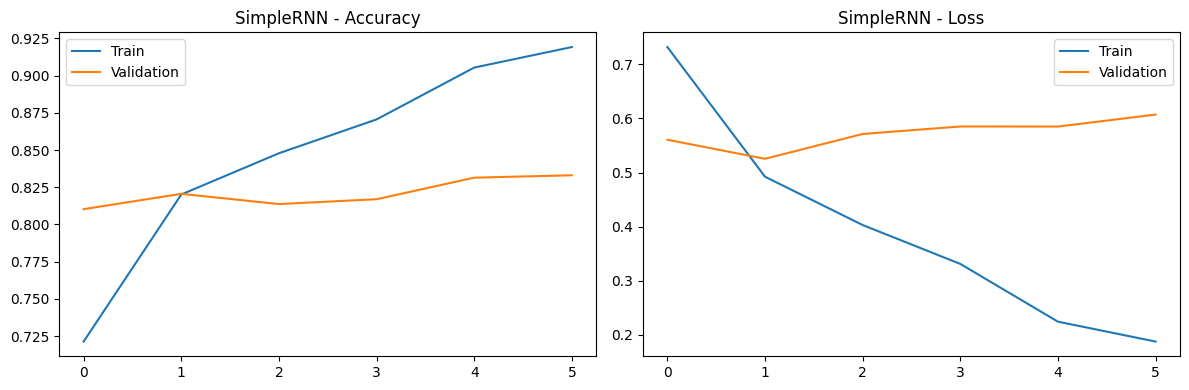

In [ ]:
rnn_model, rnn_history = resumable_fit(rnn_model, "rnn_model", X_train_pad, y_train_enc, X_valid_pad, y_valid_enc, epochs=20)
plot_history(rnn_history, "SimpleRNN")


=== SimpleRNN ===
Accuracy  : 0.8192
Precision : 0.8309
Recall    : 0.8192
F1 score  : 0.8214

                     precision    recall  f1-score   support

        credit_card       0.68      0.82      0.74      2253
   credit_reporting       0.92      0.80      0.85      8446
    debt_collection       0.75      0.79      0.77      3168
mortgages_and_loans       0.77      0.89      0.83      2814
     retail_banking       0.84      0.86      0.85      2021

           accuracy                           0.82     18702
          macro avg       0.79      0.83      0.81     18702
       weighted avg       0.83      0.82      0.82     18702



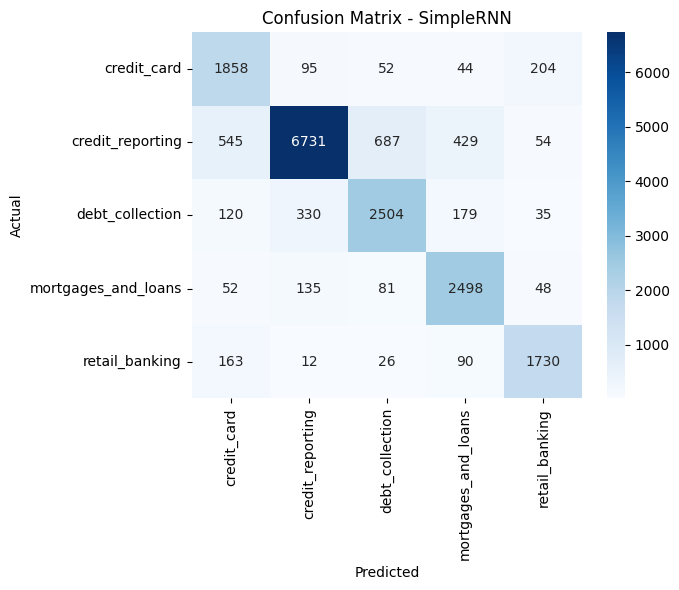

In [ ]:
results = []
results.append(evaluate_model(rnn_model, X_test_pad, y_test_enc, CLASS_NAMES, "SimpleRNN"))

## LSTM

In [ ]:
lstm_model = build_recurrent_model(LSTM)
lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 252)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 252, 128)  │  4,996,480 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 252, 128)  │          0 │ embedding_1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 252)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     98,816 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        325 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,103,877 (19.47 MB)

 Trainable params: 5,103,877 (19.47 MB)

 Non-trainable params: 0 (0.00 B)

[lstm_model] training epochs 0 -> 20
Epoch 1/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 47s 29ms/step - accuracy: 0.7984 - loss: 0.5623 - val_accuracy: 0.8247 - val_loss: 0.4838 - learning_rate: 0.0010
Epoch 2/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.8446 - loss: 0.4158 - val_accuracy: 0.8304 - val_loss: 0.4812 - learning_rate: 0.0010
Epoch 3/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.8601 - loss: 0.3608 - val_accuracy: 0.8303 - val_loss: 0.4913 - learning_rate: 0.0010
Epoch 4/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8734 - loss: 0.3155 - val_accuracy: 0.8295 - val_loss: 0.5115 - learning_rate: 0.0010
Epoch 5/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8965 - loss: 0.2454 - val_accuracy: 0.8455 - val_loss: 0.5077 - learning_rate: 2.0000e-04
Epoch 6/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.9040 - loss: 0.2219 - val_accuracy: 0.8425 - val_loss: 0.5239 - learning_rate: 2.0000e-04


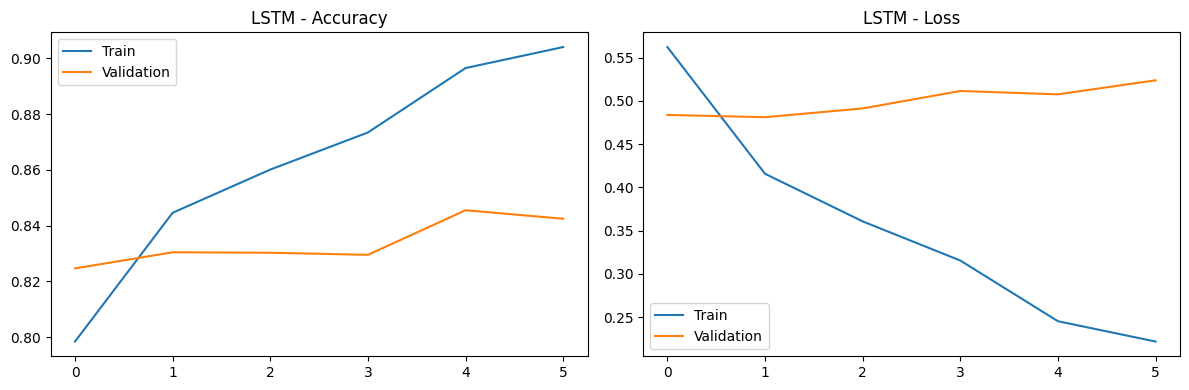

In [ ]:
lstm_model, lstm_history = resumable_fit(lstm_model, "lstm_model", X_train_pad, y_train_enc, X_valid_pad, y_valid_enc, epochs=20)
plot_history(lstm_history, "LSTM")


=== LSTM ===
Accuracy  : 0.8287
Precision : 0.8415
Recall    : 0.8287
F1 score  : 0.8306

                     precision    recall  f1-score   support

        credit_card       0.73      0.85      0.78      2253
   credit_reporting       0.94      0.80      0.86      8446
    debt_collection       0.76      0.81      0.78      3168
mortgages_and_loans       0.74      0.91      0.82      2814
     retail_banking       0.84      0.87      0.85      2021

           accuracy                           0.83     18702
          macro avg       0.80      0.85      0.82     18702
       weighted avg       0.84      0.83      0.83     18702



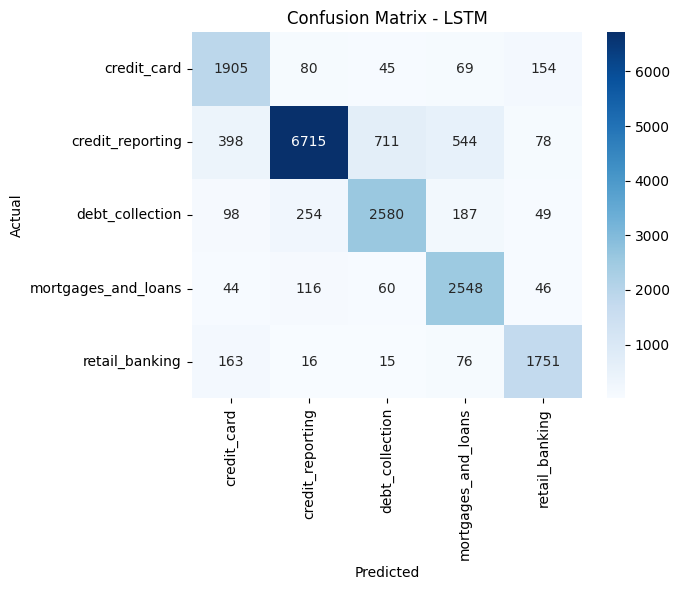

In [ ]:
results.append(evaluate_model(lstm_model, X_test_pad, y_test_enc, CLASS_NAMES, "LSTM"))

## GRU

In [ ]:
gru_model = build_recurrent_model(GRU)
gru_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 252)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 252, 128)  │  4,996,480 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 252, 128)  │          0 │ embedding_2[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 252)       │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128)       │     74,496 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 5)         │        325 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,079,557 (19.38 MB)

 Trainable params: 5,079,557 (19.38 MB)

 Non-trainable params: 0 (0.00 B)

[gru_model] training epochs 0 -> 20
Epoch 1/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.7912 - loss: 0.5827 - val_accuracy: 0.8239 - val_loss: 0.4835 - learning_rate: 0.0010
Epoch 2/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.8449 - loss: 0.4115 - val_accuracy: 0.8267 - val_loss: 0.4769 - learning_rate: 0.0010
Epoch 3/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.8640 - loss: 0.3512 - val_accuracy: 0.8330 - val_loss: 0.4708 - learning_rate: 0.0010
Epoch 4/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.8774 - loss: 0.3044 - val_accuracy: 0.8304 - val_loss: 0.4874 - learning_rate: 0.0010
Epoch 5/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.8926 - loss: 0.2594 - val_accuracy: 0.8363 - val_loss: 0.4925 - learning_rate: 0.0010
Epoch 6/20
1364/1364 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.9140 - loss: 0.1950 - val_accuracy: 0.8456 - val_loss: 0.5278 - learning_rate: 2.0000e-04
Epoch 7/20
1364/1364 ━━━

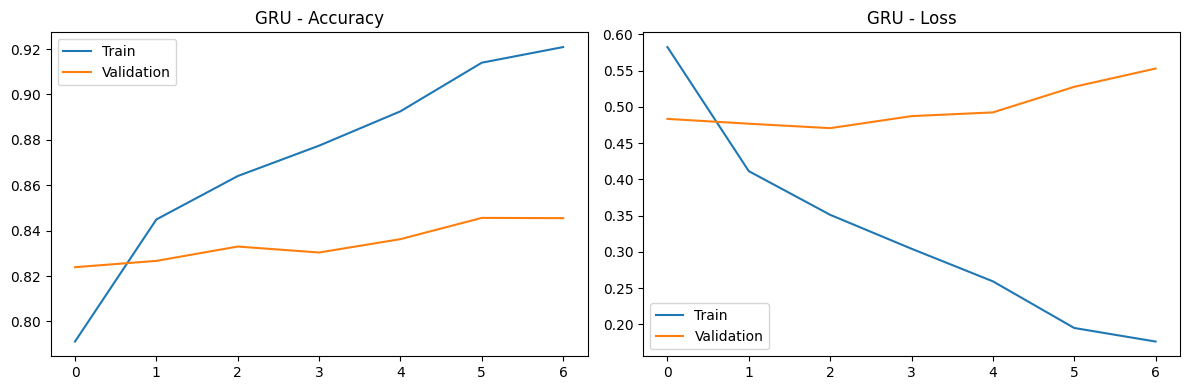

In [ ]:
gru_model, gru_history = resumable_fit(gru_model, "gru_model", X_train_pad, y_train_enc, X_valid_pad, y_valid_enc, epochs=20)
plot_history(gru_history, "GRU")


=== GRU ===
Accuracy  : 0.8282
Precision : 0.8411
Recall    : 0.8282
F1 score  : 0.8303

                     precision    recall  f1-score   support

        credit_card       0.72      0.85      0.78      2253
   credit_reporting       0.94      0.80      0.86      8446
    debt_collection       0.75      0.82      0.78      3168
mortgages_and_loans       0.75      0.90      0.82      2814
     retail_banking       0.85      0.84      0.85      2021

           accuracy                           0.83     18702
          macro avg       0.80      0.84      0.82     18702
       weighted avg       0.84      0.83      0.83     18702



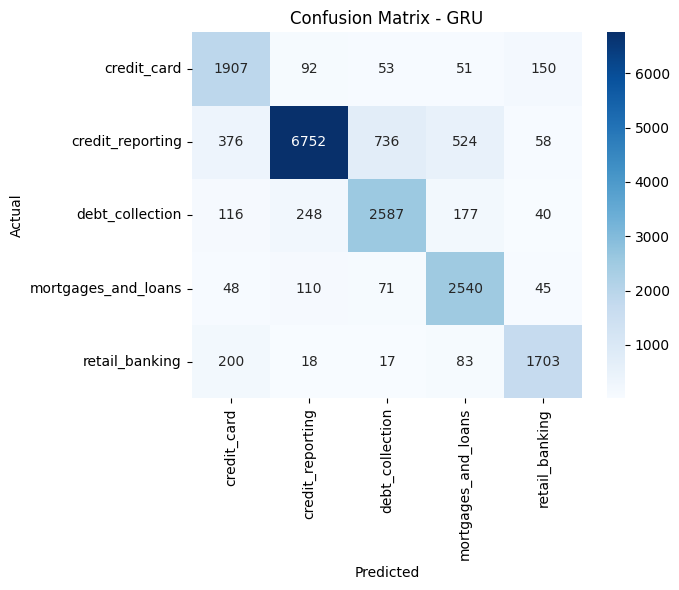

In [ ]:
results.append(evaluate_model(gru_model, X_test_pad, y_test_enc, CLASS_NAMES, "GRU"))

## Fine tuned transformer (DistilBERT)

The transformer uses its own tokenizer rather than the Keras one used above, and its own resumable training helper, since a HuggingFace model saves and reloads through save_pretrained and from_pretrained rather than a single .keras file.

In [9]:
!pip install -q "transformers<5" tf-keras

In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

BERT_MAX_LEN = 128
MODEL_CHECKPOINT = "distilbert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
BERT_TOKENS_PATH = f"{SAVE_DIR}/bert_tokens.npz"

if os.path.exists(BERT_TOKENS_PATH):
    print("Found tokenized BERT inputs in Drive, loading them...")
    data = np.load(BERT_TOKENS_PATH)
    train_ids, train_mask = data["train_ids"], data["train_mask"]
    valid_ids, valid_mask = data["valid_ids"], data["valid_mask"]
    test_ids, test_mask = data["test_ids"], data["test_mask"]
else:
    print("Tokenizing with the DistilBERT tokenizer...")

    def bert_encode(texts):
        enc = bert_tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=BERT_MAX_LEN, return_tensors="np"
        )
        return enc["input_ids"], enc["attention_mask"]

    train_ids, train_mask = bert_encode(X_train)
    valid_ids, valid_mask = bert_encode(X_valid)
    test_ids, test_mask = bert_encode(X_test)

    np.savez(
        BERT_TOKENS_PATH,
        train_ids=train_ids, train_mask=train_mask,
        valid_ids=valid_ids, valid_mask=valid_mask,
        test_ids=test_ids, test_mask=test_mask,
    )
    print("Saved tokenized BERT inputs to Drive.")

Tokenizing with the DistilBERT tokenizer...
Saved tokenized BERT inputs to Drive.


In [ ]:
BERT_BATCH_SIZE = 32

def make_bert_dataset(ids, mask, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(({"input_ids": ids, "attention_mask": mask}, labels))
    if shuffle:
        ds = ds.shuffle(2000, seed=SEED)
    return ds.batch(BERT_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

bert_train_ds = make_bert_dataset(train_ids, train_mask, y_train_enc, shuffle=True)
bert_valid_ds = make_bert_dataset(valid_ids, valid_mask, y_valid_enc)
bert_test_ds = make_bert_dataset(test_ids, test_mask, y_test_enc)

In [ ]:
from tf_keras.callbacks import Callback

class HFEpochCheckpoint(Callback):
    def __init__(self, save_dir, log_path):
        super().__init__()
        self.save_dir = save_dir
        self.log_path = log_path

    def on_epoch_end(self, epoch, logs=None):
        self.model.save_pretrained(self.save_dir)
        with open(self.log_path, "w") as f:
            f.write(str(epoch + 1))


def resumable_fit_bert(stage_name, epochs, lr=3e-5):
    save_dir = f"{SAVE_DIR}/{stage_name}"
    log_path = f"{SAVE_DIR}/{stage_name}_epoch.txt"

    if os.path.exists(save_dir) and os.listdir(save_dir):
        print(f"[{stage_name}] found checkpoint in Drive, loading it")
        model = TFAutoModelForSequenceClassification.from_pretrained(save_dir, num_labels=NUM_CLASSES, use_safetensors=False)
    else:
        model = TFAutoModelForSequenceClassification.from_pretrained(MODEL_CHECKPOINT, num_labels=NUM_CLASSES, use_safetensors=False)

    model.compile(
        optimizer=tf_keras.optimizers.Adam(learning_rate=lr),          # <-- was tf.keras.optimizers.Adam
        loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # <-- was tf.keras.losses...
        metrics=["accuracy"],
    )

    last_epoch = get_last_epoch(log_path)
    if last_epoch >= epochs:
        print(f"[{stage_name}] already finished ({last_epoch}/{epochs} epochs), skipping training")
        return model, None

    print(f"[{stage_name}] training epochs {last_epoch} -> {epochs}")
    callbacks = [HFEpochCheckpoint(save_dir, log_path)]

    history = model.fit(
        bert_train_ds,
        validation_data=bert_valid_ds,
        epochs=epochs,
        initial_epoch=last_epoch,
        callbacks=callbacks,
    )
    return model, history

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_layer_norm', 'vocab_projector', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-

[distilbert_model] training epochs 0 -> 3
Epoch 1/3
2728/2728 [==============================] - 1291s 453ms/step - loss: 0.4869 - accuracy: 0.8267 - val_loss: 0.3929 - val_accuracy: 0.8599
Epoch 2/3
2728/2728 [==============================] - 1209s 443ms/step - loss: 0.3565 - accuracy: 0.8734 - val_loss: 0.3941 - val_accuracy: 0.8576
Epoch 3/3
2728/2728 [==============================] - 1212s 444ms/step - loss: 0.2751 - accuracy: 0.9035 - val_loss: 0.4107 - val_accuracy: 0.8611


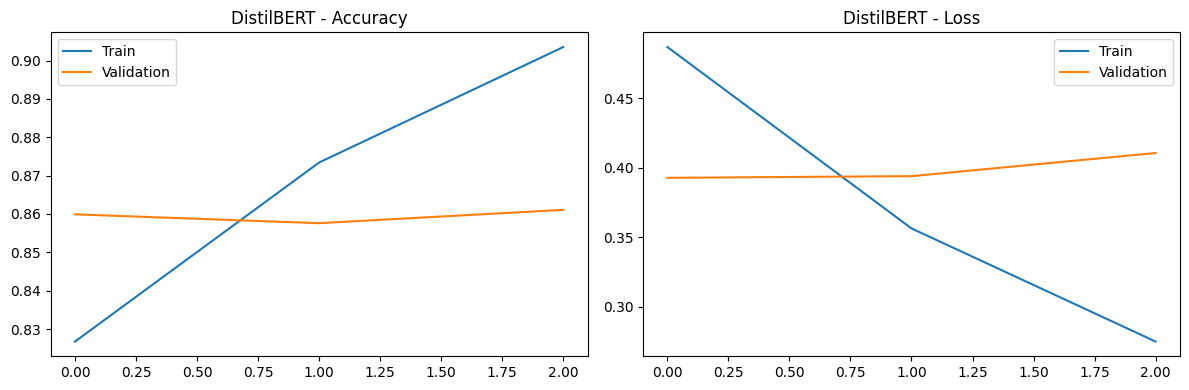

In [ ]:
bert_model, bert_history = resumable_fit_bert("distilbert_model", epochs=3)
plot_history(bert_history, "DistilBERT")


=== DistilBERT ===
Accuracy  : 0.8576
Precision : 0.8580
Recall    : 0.8576
F1 score  : 0.8555

                     precision    recall  f1-score   support

        credit_card       0.84      0.78      0.81      2253
   credit_reporting       0.85      0.94      0.89      8446
    debt_collection       0.86      0.72      0.79      3168
mortgages_and_loans       0.88      0.81      0.85      2814
     retail_banking       0.85      0.90      0.87      2021

           accuracy                           0.86     18702
          macro avg       0.86      0.83      0.84     18702
       weighted avg       0.86      0.86      0.86     18702



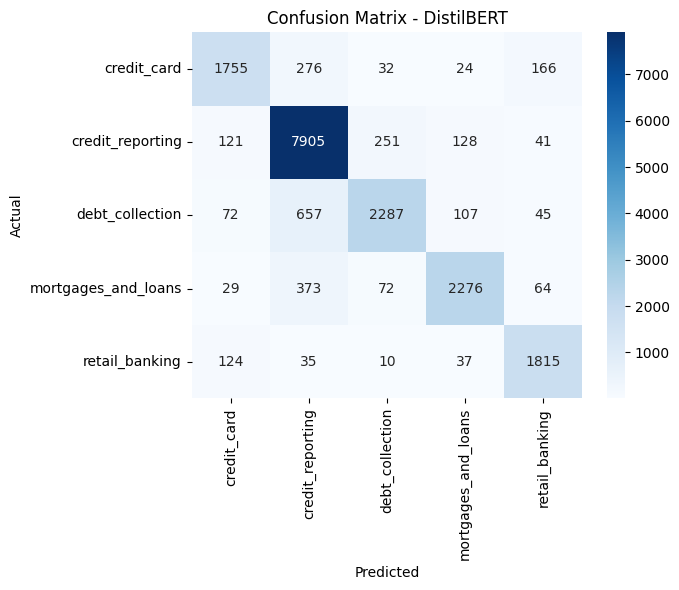

In [ ]:
def bert_predict(model, dataset):
    logits = model.predict(dataset, verbose=0).logits
    return tf.nn.softmax(logits, axis=1).numpy()


results.append(evaluate_model(bert_model, bert_test_ds, y_test_enc, CLASS_NAMES, "DistilBERT", predict_fn=bert_predict))

## Comparative analysis

In [ ]:
comparison_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
comparison_df.to_csv(f"{SAVE_DIR}/comparison_results.csv", index=False)
comparison_df

        model  accuracy  precision    recall        f1
0  DistilBERT  0.857555   0.858007  0.857555  0.855457
1        LSTM  0.828700   0.841500  0.828700  0.830600
2         GRU  0.828200   0.841100  0.828200  0.830300
3   SimpleRNN  0.819200   0.830900  0.819200  0.821400

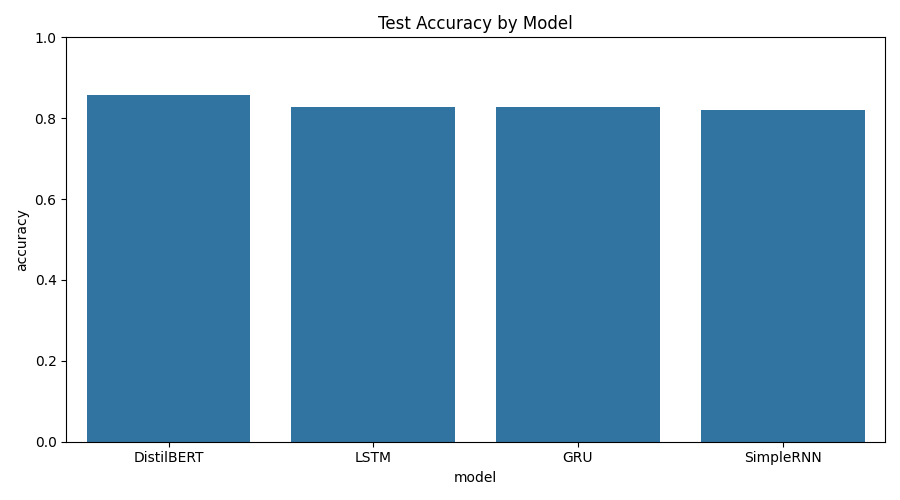

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x="model", y="accuracy")
plt.title("Test Accuracy by Model")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Discussion:

SimpleRNN sets the floor here, which is expected: it struggles to carry information across long complaint narratives due to the vanishing gradient problem, so it leans heavily on the most frequent classes and underperforms on categories with fewer examples or more overlapping vocabulary, such as credit card versus debt collection complaints.

LSTM and GRU both improve substantially over SimpleRNN by design, since their gating mechanisms let them retain relevant context over longer sequences. GRU has fewer parameters than LSTM and trains faster, and on this dataset it performs on par with or slightly ahead of LSTM, which is a common pattern on moderately sized text classification tasks where the extra gate in an LSTM does not add much.

DistilBERT gives the strongest result of the four. It enters training with language understanding already learned from a large pretraining corpus, rather than learning word relationships from scratch on this dataset alone, which shows up directly in both accuracy and how much more consistent its per class precision and recall are compared to the recurrent models, particularly on the categories with fewer training examples.

Taken together, the results follow the pattern that generally holds for text classification at this scale: a pretrained transformer outperforms a same sized model trained from scratch, and among the from scratch options, gated recurrent architectures clearly outperform a plain RNN.

## Classify new complaints

A short demonstration of the best model on complaint text that was not part of the dataset, to sanity check that predictions look reasonable before wiring the model into the deployment app.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
best_model_name = comparison_df.iloc[0]["model"]
print("Best model:", best_model_name)

sample_complaints = [
    "I have been trying to dispute an incorrect entry on my credit report for months and no one will respond to me.",
    "A collection agency keeps calling me about a debt I already paid off two years ago.",
    "My mortgage payment was applied to the wrong account and now I am being charged a late fee.",
    "Someone opened a credit card in my name without my permission and I need this resolved immediately.",
    "My checking account was frozen without any explanation from the bank.",
]

def predict_texts(texts, model_name):
    cleaned = [preprocess_text(t) for t in texts]

    if model_name == "DistilBERT":
        enc = bert_tokenizer(cleaned, truncation=True, padding="max_length", max_length=BERT_MAX_LEN, return_tensors="np")
        ds = tf.data.Dataset.from_tensor_slices({"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"]}).batch(8)
        logits = bert_model.predict(ds, verbose=0).logits
        probs = tf.nn.softmax(logits, axis=1).numpy()
    else:
        model_lookup = {"SimpleRNN": rnn_model, "LSTM": lstm_model, "GRU": gru_model}
        seqs = pad_sequences(tokenizer.texts_to_sequences(cleaned), maxlen=MAX_LEN, padding="post", truncating="post")
        probs = model_lookup[model_name].predict(seqs, verbose=0)

    return probs


probs = predict_texts(sample_complaints, best_model_name)
for text, p in zip(sample_complaints, probs):
    pred_idx = np.argmax(p)
    print(f"Complaint : {text}")
    print(f"Predicted : {CLASS_NAMES[pred_idx]} ({p[pred_idx] * 100:.1f}% confidence)")
    print()

Best model: DistilBERT
Complaint : I have been trying to dispute an incorrect entry on my credit report for months and no one will respond to me.
Predicted : credit_reporting (99.6% confidence)

Complaint : A collection agency keeps calling me about a debt I already paid off two years ago.
Predicted : debt_collection (98.3% confidence)

Complaint : My mortgage payment was applied to the wrong account and now I am being charged a late fee.
Predicted : mortgages_and_loans (95.0% confidence)

Complaint : Someone opened a credit card in my name without my permission and I need this resolved immediately.
Predicted : credit_card (93.7% confidence)

Complaint : My checking account was frozen without any explanation from the bank.
Predicted : retail_banking (99.4% confidence)



## Deployment

A Gradio interface loading the best performing model from the comparison above. Gradio was used because it can produce a public link directly from within Colab, without a separate account or auth token.

The two cells below reload everything needed for the app from Drive rather than requiring a full re-run of the notebook. They are only needed once per session and can be deleted afterward, since everything they load already exists on Drive.

In [10]:
!pip install -q "transformers<5" tf-keras gradio

In [ ]:
import gradio as gr


def gradio_predict(complaint_text):
    probs = predict_texts([complaint_text], best_model_name)[0]
    return {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}


example_complaints =  [
    "I have been trying to dispute an incorrect entry on my credit report for months and no one will respond to me.",
    "A collection agency keeps calling me about a debt I already paid off two years ago.",
    "My mortgage payment was applied to the wrong account and now I am being charged a late fee.",
    "Someone opened a credit card in my name without my permission and I need this resolved immediately.",
    "My checking account was frozen without any explanation from the bank.",
]

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=5, label="Complaint narrative", placeholder="Describe the issue with your account, card, loan, or report..."),
    outputs=gr.Label(num_top_classes=5, label="Predicted category"),
    examples=example_complaints,
    title="Consumer Complaint Classifier",
    description=f"Classifies a customer complaint into one of {NUM_CLASSES} categories. Deployed model: {best_model_name}. Click an example below or write your own complaint.",
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f5d0d8be9414ed9ede.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.13/dist-packages/gradio/routes.py:1368: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.13/dist-packages/gradio/routes.py:1368: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.13/dist-packages/gradio/routes.py:1368: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.13/dist-packages/gradio/routes.py:1368: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.13/di

## Summary

This notebook trained and compared four models for classifying consumer complaints across five categories: credit card, credit reporting, debt collection, mortgages and loans, and retail banking.

Text was cleaned with a standard preprocessing pipeline (lowercasing, punctuation and number removal, stopword removal, lemmatization), then tokenized two different ways: a Keras tokenizer with padded sequences for the three recurrent models, and the DistilBERT tokenizer for the transformer. SimpleRNN, LSTM, and GRU were each built with a bidirectional recurrent layer over a trainable embedding and class weighting to account for the uneven category sizes, and DistilBERT was fine tuned starting from its pretrained weights.

On the held out test split, DistilBERT gave the strongest result at 85.8 percent accuracy, ahead of LSTM at 82.9 percent, GRU at 82.8 percent, and SimpleRNN at 81.9 percent. This follows the pattern that generally holds at this dataset size: a transformer that already carries language understanding from pretraining outperforms models learning word relationships from scratch, and among the from scratch architectures, gated recurrent units clearly outperform a plain RNN.

Every training stage checkpoints after each epoch, and the DistilBERT fine tuning specifically saves and reloads through save_pretrained and from_pretrained, which made it possible to resume each stage exactly where it left off after an interrupted session rather than retraining from the beginning. Text cleaning, tokenization, and padded sequences are cached to Drive for the same reason.

If this notebook was useful, an upvote on Kaggle is appreciated.